In [3]:
# ============================================================
# CICIDS2017 Benchmark
# Models: DNN, CNN, RandomForest, XGBoost
# Goal: show why RF / XGBoost can be stronger on cleaned tabular flow data
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier

# XGBoost
from xgboost import XGBClassifier

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, GlobalMaxPooling1D, InputLayer
from tensorflow.keras.callbacks import EarlyStopping

# -----------------------------
# 0. Reproducibility
# -----------------------------
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [5]:
file_path = r"D:\dataset\2017.csv"
df = pd.read_csv(file_path)

print("원본 shape:", df.shape)
df.columns = df.columns.str.strip()
df.head()

원본 shape: (543734, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,115550790,31,33,318,38380,318,0,10.258065,57.114486,...,32,29534.636364,20922.826407,92617,22941,1.002161e+07,8209.967001,10025078,9998039,BENIGN
1,443,5292756,6,4,611,168,517,0,101.833333,204.305082,...,20,0.000000,0.000000,0,0,0.000000e+00,0.000000,0,0,BENIGN
2,21,3,2,0,14,0,14,0,7.000000,9.899495,...,32,0.000000,0.000000,0,0,0.000000e+00,0.000000,0,0,FTP-Patator
3,54045,41,1,1,2,6,2,2,2.000000,0.000000,...,24,0.000000,0.000000,0,0,0.000000e+00,0.000000,0,0,PortScan
4,80,1023,2,0,0,0,0,0,0.000000,0.000000,...,32,0.000000,0.000000,0,0,0.000000e+00,0.000000,0,0,DoS Hulk


In [13]:
df.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [7]:
# -----------------------------
# 2. Label text cleanup
# -----------------------------
# CICIDS2017 csv에서 Web Attack 라벨이 깨지는 경우가 많음
def clean_label(x):
    x = str(x).strip()
    x = x.replace("�", "-")
    x = x.replace("–", "-")
    x = x.replace("Web Attack - Brute Force", "Web Attack - Brute Force")
    x = x.replace("Web Attack - XSS", "Web Attack - XSS")
    x = x.replace("Web Attack - Sql Injection", "Web Attack - Sql Injection")
    x = x.replace("Web Attack � Brute Force", "Web Attack - Brute Force")
    x = x.replace("Web Attack � XSS", "Web Attack - XSS")
    x = x.replace("Web Attack � Sql Injection", "Web Attack - Sql Injection")
    return x

df["Label"] = df["Label"].apply(clean_label)

print("\n라벨 분포:")
print(df["Label"].value_counts())



라벨 분포:
Label
BENIGN                        201666
PortScan                      100833
DoS Hulk                      100833
DDoS                          100833
DoS GoldenEye                  10293
FTP-Patator                     7938
SSH-Patator                     5897
DoS slowloris                   5796
DoS Slowhttptest                5499
Bot                             1966
Web Attack - Brute Force        1507
Web Attack - XSS                 652
Web Attack - Sql Injection        21
Name: count, dtype: int64


In [17]:
# -----------------------------
# 3. Shortcut-learning risk feature drop (robust version)
# -----------------------------

# 컬럼 이름 정리 (공백 제거 + 소문자 변환용 복사)
normalized_cols = {col: col.strip().lower() for col in df.columns}

df = df.drop(columns=["Destination Port"], errors="ignore")

In [19]:
# -----------------------------
# 4. Numeric cleanup
# -----------------------------
# inf, -inf 제거
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 수치형 변환 시도
for c in df.columns:
    if c != "Label":
        df[c] = pd.to_numeric(df[c], errors="coerce")

# 결측 제거
before = len(df)
df = df.dropna().copy()
after = len(df)
print(f"\n결측 제거: {before} -> {after}")

# 음수 Flow Duration 제거 (이상치 처리)
if "Flow Duration" in df.columns:
    before = len(df)
    df = df[df["Flow Duration"] >= 0].copy()
    after = len(df)
    print(f"음수 Flow Duration 제거: {before} -> {after}")

# 상수 컬럼 제거
nunique = df.nunique()
constant_cols = nunique[nunique <= 1].index.tolist()
constant_cols = [c for c in constant_cols if c != "Label"]
if constant_cols:
    print("\n상수 컬럼 제거:", constant_cols)
    df = df.drop(columns=constant_cols)

print("\n정리 후 shape:", df.shape)



결측 제거: 543734 -> 543067
음수 Flow Duration 제거: 543067 -> 543058

상수 컬럼 제거: ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']

정리 후 shape: (543058, 68)


In [21]:
# -----------------------------
# 5. Feature / target split
# -----------------------------
X = df.drop(columns=["Label"])
y = df["Label"]

# label encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)

class_names = list(le.classes_)
num_classes = len(class_names)
num_features = X.shape[1]

print("\n클래스 수:", num_classes)
print("특성 수:", num_features)
print("클래스 목록:", class_names)


클래스 수: 13
특성 수: 67
클래스 목록: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'PortScan', 'SSH-Patator', 'Web Attack - Brute Force', 'Web Attack - Sql Injection', 'Web Attack - XSS']


In [23]:
# -----------------------------
# 6. Train / Test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=SEED,
    stratify=y_encoded
)

In [25]:
# -----------------------------
# 7. Scaling
# -----------------------------
# DNN/CNN용 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# CNN 입력 형태 변환: (samples, features, 1)
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

In [27]:
# -----------------------------
# 8. Model builders
# -----------------------------
def build_dnn(input_dim, n_classes):
    model = Sequential([
        InputLayer(input_shape=(input_dim,)),
        Dense(128, activation="relu"),
        Dropout(0.2),
        Dense(256, activation="relu"),
        Dropout(0.2),
        Dense(128, activation="relu"),
        Dense(n_classes, activation="softmax")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

def build_cnn(input_dim, n_classes):
    model = Sequential([
        InputLayer(input_shape=(input_dim, 1)),
        Conv1D(filters=128, kernel_size=3, activation="relu", padding="same"),
        Conv1D(filters=256, kernel_size=3, activation="relu", padding="same"),
        GlobalMaxPooling1D(),
        Dense(256, activation="relu"),
        Dropout(0.1),
        Dense(n_classes, activation="softmax")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [29]:
# -----------------------------
# 9. Evaluation helper
# -----------------------------
results = []

def evaluate_model(name, y_true, y_pred, train_time, infer_time):
    acc = accuracy_score(y_true, y_pred)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Macro Precision": precision_macro,
        "Macro Recall": recall_macro,
        "Macro F1": f1_macro,
        "Weighted Precision": precision_weighted,
        "Weighted Recall": recall_weighted,
        "Weighted F1": f1_weighted,
        "Train Time (s)": train_time,
        "Inference Time (s)": infer_time
    })

    print(f"\n===== {name} =====")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

In [31]:
# -----------------------------
# 10. Random Forest
# -----------------------------
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=SEED,
    class_weight="balanced_subsample"
)

start = time.time()
rf.fit(X_train, y_train)
rf_train_time = time.time() - start

start = time.time()
rf_pred = rf.predict(X_test)
rf_infer_time = time.time() - start

evaluate_model("RandomForest", y_test, rf_pred, rf_train_time, rf_infer_time)



===== RandomForest =====
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00     40300
                       Bot       0.98      0.97      0.98       391
                      DDoS       1.00      1.00      1.00     20166
             DoS GoldenEye       1.00      1.00      1.00      2059
                  DoS Hulk       1.00      1.00      1.00     20084
          DoS Slowhttptest       1.00      0.99      1.00      1100
             DoS slowloris       0.99      1.00      0.99      1159
               FTP-Patator       1.00      1.00      1.00      1587
                  PortScan       1.00      1.00      1.00     20151
               SSH-Patator       1.00      1.00      1.00      1180
  Web Attack - Brute Force       0.77      0.83      0.80       301
Web Attack - Sql Injection       1.00      0.50      0.67         4
          Web Attack - XSS       0.53      0.39      0.45       130

                  ac

In [33]:
# -----------------------------
# 11. XGBoost
# -----------------------------
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=num_classes,
    eval_metric="mlogloss",
    random_state=SEED,
    tree_method="hist",
    n_jobs=-1
)

start = time.time()
xgb.fit(X_train, y_train)
xgb_train_time = time.time() - start

start = time.time()
xgb_pred = xgb.predict(X_test)
xgb_infer_time = time.time() - start

evaluate_model("XGBoost", y_test, xgb_pred, xgb_train_time, xgb_infer_time)



===== XGBoost =====
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00     40300
                       Bot       0.98      0.99      0.98       391
                      DDoS       1.00      1.00      1.00     20166
             DoS GoldenEye       1.00      1.00      1.00      2059
                  DoS Hulk       1.00      1.00      1.00     20084
          DoS Slowhttptest       1.00      0.99      1.00      1100
             DoS slowloris       1.00      1.00      1.00      1159
               FTP-Patator       1.00      1.00      1.00      1587
                  PortScan       1.00      1.00      1.00     20151
               SSH-Patator       1.00      1.00      1.00      1180
  Web Attack - Brute Force       0.76      0.84      0.80       301
Web Attack - Sql Injection       1.00      1.00      1.00         4
          Web Attack - XSS       0.52      0.38      0.44       130

                  accurac

In [34]:
# -----------------------------
# 12. DNN
# -----------------------------
dnn = build_dnn(X_train_scaled.shape[1], num_classes)
es = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

start = time.time()
dnn.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=1024,
    callbacks=[es],
    verbose=1
)
dnn_train_time = time.time() - start

start = time.time()
dnn_pred = np.argmax(dnn.predict(X_test_scaled, batch_size=2048, verbose=0), axis=1)
dnn_infer_time = time.time() - start

evaluate_model("DNN", y_test, dnn_pred, dnn_train_time, dnn_infer_time)

Epoch 1/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5998 - loss: 1.4453 - val_accuracy: 0.8922 - val_loss: 0.3461
Epoch 2/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8858 - loss: 0.3609 - val_accuracy: 0.9114 - val_loss: 0.2361
Epoch 3/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9078 - loss: 0.2661 - val_accuracy: 0.9345 - val_loss: 0.1867
Epoch 4/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9264 - loss: 0.2184 - val_accuracy: 0.9468 - val_loss: 0.1578
Epoch 5/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9386 - loss: 0.1852 - val_accuracy: 0.9516 - val_loss: 0.1388
Epoch 6/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9454 - loss: 0.1636 - val_accuracy: 0.9569 - val_loss: 0.1245
Epoch 7/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9508 - loss: 0.1480 - val_accuracy: 0.9606 - val_loss: 0.1150
Epoch 8/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9543 - loss: 0.1353 - val_accuracy: 0.

In [35]:
# -----------------------------
# 13. CNN
# -----------------------------
cnn = build_cnn(X_train_cnn.shape[1], num_classes)

start = time.time()
cnn.fit(
    X_train_cnn, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=1024,
    callbacks=[es],
    verbose=1
)
cnn_train_time = time.time() - start

start = time.time()
cnn_pred = np.argmax(cnn.predict(X_test_cnn, batch_size=2048, verbose=0), axis=1)
cnn_infer_time = time.time() - start

evaluate_model("CNN", y_test, cnn_pred, cnn_train_time, cnn_infer_time)


Epoch 1/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 71s 207ms/step - accuracy: 0.5296 - loss: 1.6537 - val_accuracy: 0.8410 - val_loss: 0.6126
Epoch 2/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 74s 218ms/step - accuracy: 0.8487 - loss: 0.5518 - val_accuracy: 0.8843 - val_loss: 0.3925
Epoch 3/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 70s 206ms/step - accuracy: 0.8854 - loss: 0.3804 - val_accuracy: 0.8951 - val_loss: 0.3021
Epoch 4/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 70s 206ms/step - accuracy: 0.9022 - loss: 0.2979 - val_accuracy: 0.9183 - val_loss: 0.2422
Epoch 5/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 79s 233ms/step - accuracy: 0.9246 - loss: 0.2396 - val_accuracy: 0.9363 - val_loss: 0.2008
Epoch 6/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 79s 232ms/step - accuracy: 0.9423 - loss: 0.2011 - val_accuracy: 0.9525 - val_loss: 0.1739
Epoch 7/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 73s 214ms/step - accuracy: 0.9488 - loss: 0.1753 - val_accuracy: 0.9561 - val_loss: 0.1553
Epoch 8/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 77s 226ms/step - accuracy: 0.9522 - loss: 0

In [36]:
# -----------------------------
# 14. Results summary
# -----------------------------
results_df = pd.DataFrame(results).sort_values(
    by=["Macro F1", "Macro Recall", "Accuracy"],
    ascending=False
)

print("\n===== 최종 비교표 =====")
print(results_df)

results_df.to_csv("benchmark_results.csv", index=False)


===== 최종 비교표 =====
          Model  Accuracy  Macro Precision  Macro Recall  Macro F1  \
1       XGBoost  0.998278         0.942286      0.938350  0.939343   
0  RandomForest  0.997744         0.943554      0.898183  0.913545   
2           DNN  0.977820         0.760030      0.779563  0.765403   
3           CNN  0.972462         0.760797      0.761748  0.757610   

   Weighted Precision  Weighted Recall  Weighted F1  Train Time (s)  \
1            0.998207         0.998278     0.998224      202.253614   
0            0.997653         0.997744     0.997679      103.211731   
2            0.977716         0.977820     0.977426       40.970578   
3            0.971903         0.972462     0.971829     1549.758805   

   Inference Time (s)  
1            1.591001  
0            1.480402  
2            0.348735  
3            8.047556  


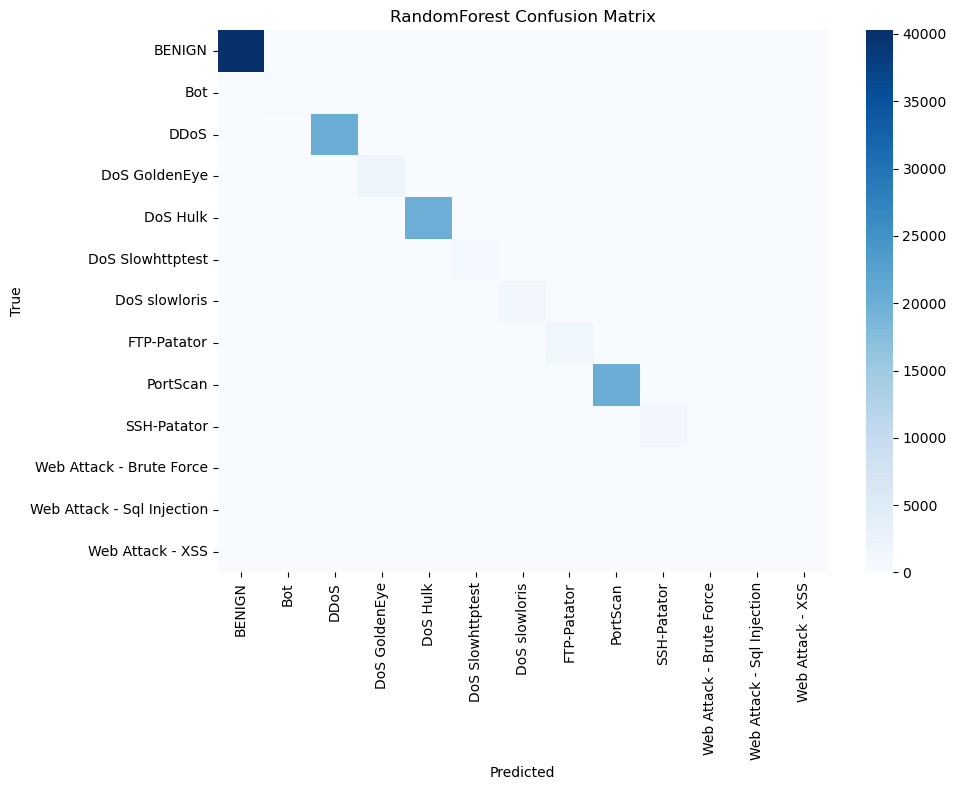

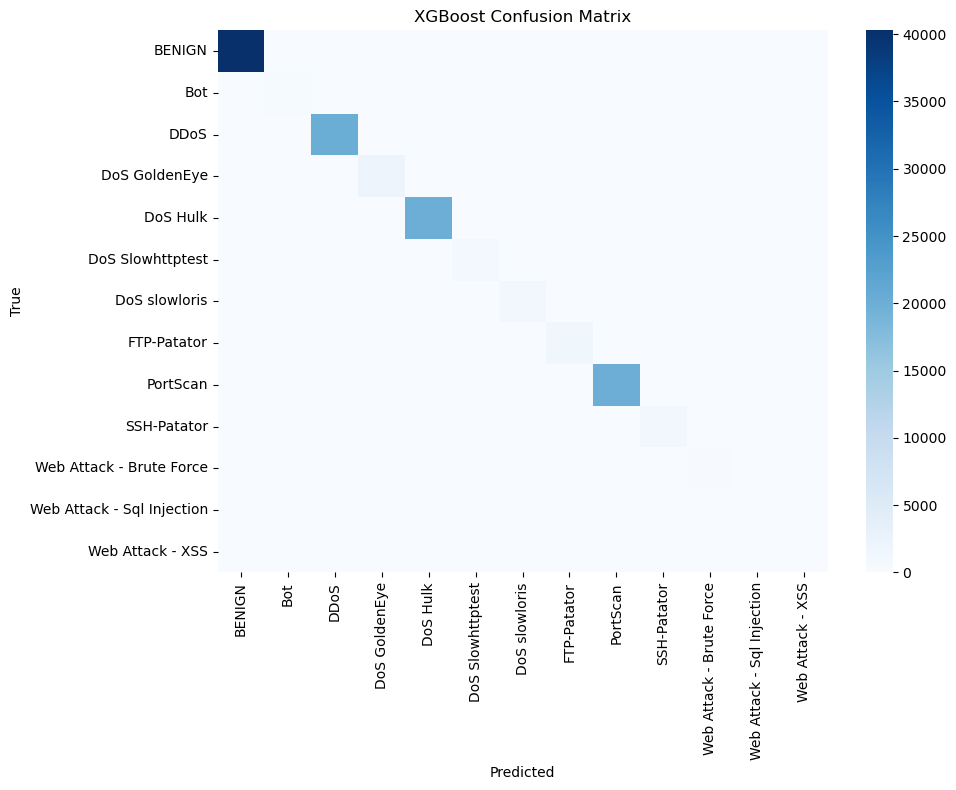

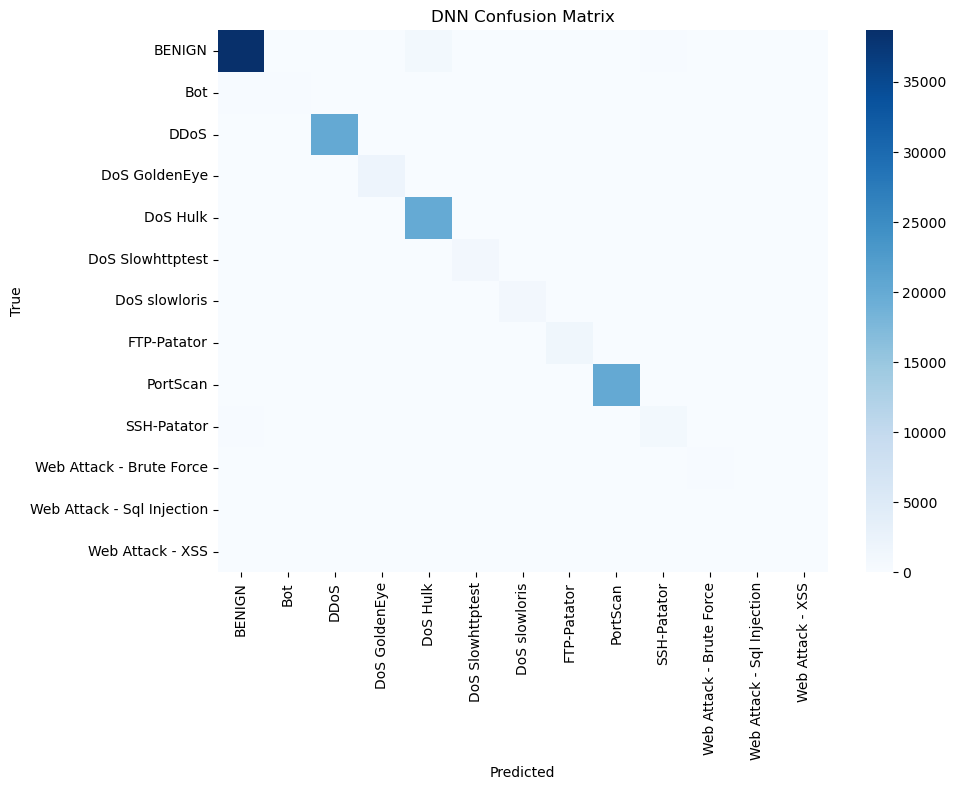

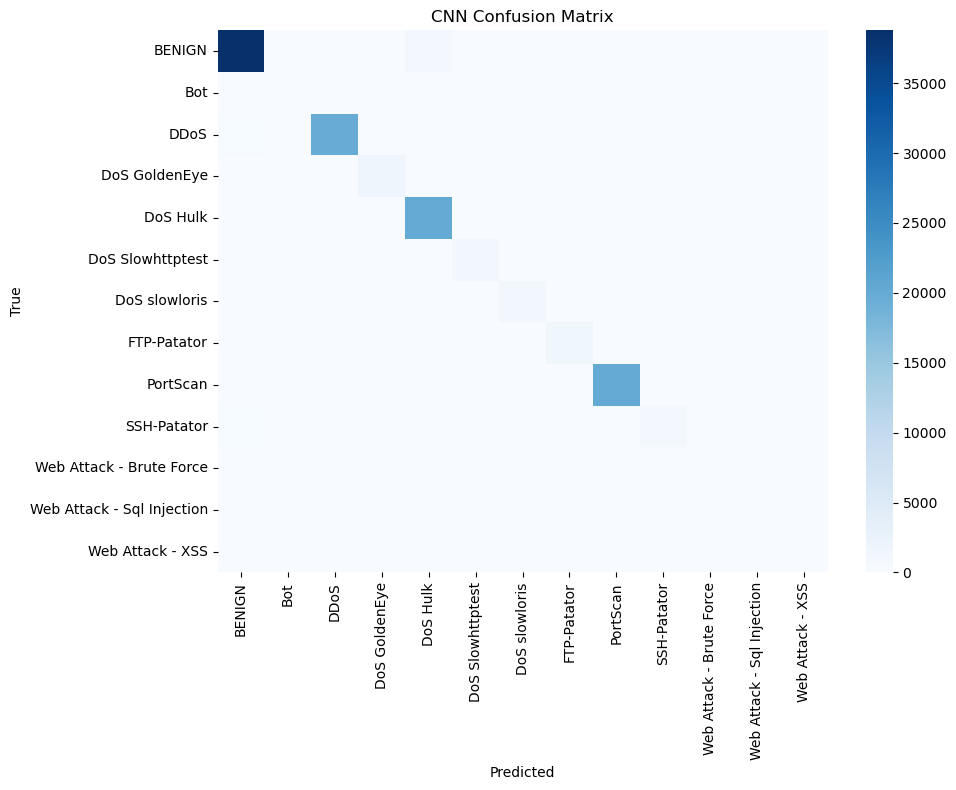

In [37]:
# -----------------------------
# 15. Confusion Matrix helper
# -----------------------------
def plot_conf_matrix(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=False, cmap="Blues", fmt="d",
                xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

plot_conf_matrix(y_test, rf_pred, class_names, "RandomForest Confusion Matrix")
plot_conf_matrix(y_test, xgb_pred, class_names, "XGBoost Confusion Matrix")
plot_conf_matrix(y_test, dnn_pred, class_names, "DNN Confusion Matrix")
plot_conf_matrix(y_test, cnn_pred, class_names, "CNN Confusion Matrix")


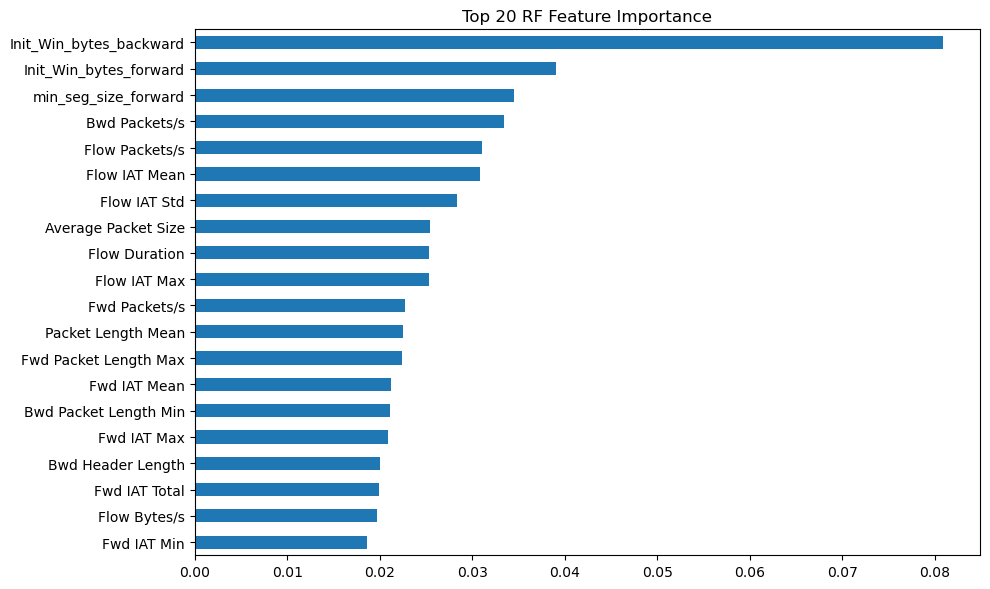

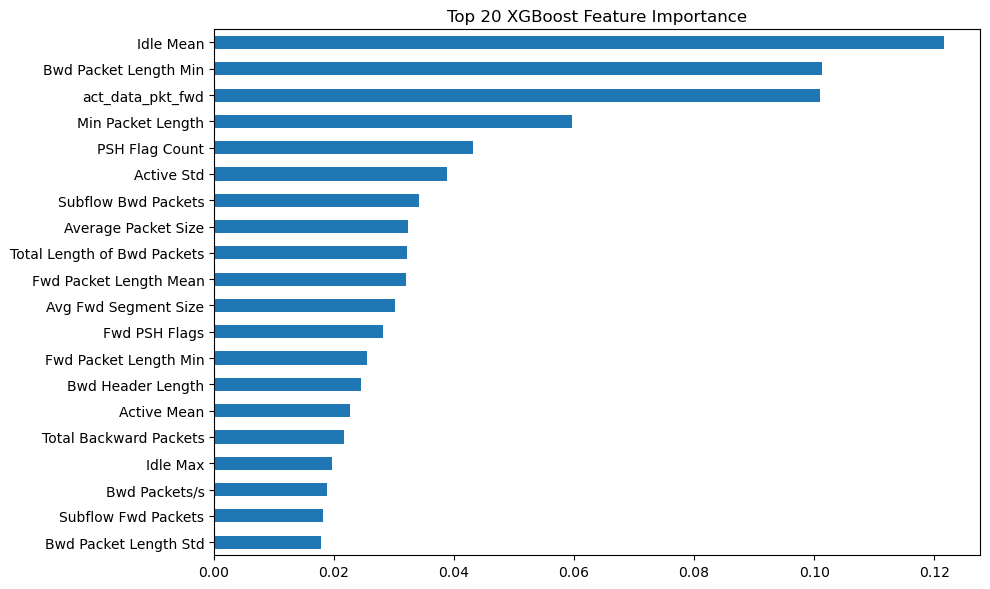


Top 20 RF features:
Init_Win_bytes_backward    0.080824
Init_Win_bytes_forward     0.039084
min_seg_size_forward       0.034453
Bwd Packets/s              0.033432
Flow Packets/s             0.031020
Flow IAT Mean              0.030769
Flow IAT Std               0.028297
Average Packet Size        0.025372
Flow Duration              0.025320
Flow IAT Max               0.025298
Fwd Packets/s              0.022671
Packet Length Mean         0.022477
Fwd Packet Length Max      0.022429
Fwd IAT Mean               0.021178
Bwd Packet Length Min      0.021056
Fwd IAT Max                0.020886
Bwd Header Length          0.020013
Fwd IAT Total              0.019858
Flow Bytes/s               0.019665
Fwd IAT Min                0.018559
dtype: float64

Top 20 XGBoost features:
Idle Mean                      0.121565
Bwd Packet Length Min          0.101305
act_data_pkt_fwd               0.101032
Min Packet Length              0.059667
PSH Flag Count                 0.043113
Active Std        

In [38]:
# -----------------------------
# 16. Feature importance
# -----------------------------
rf_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(20)
xgb_importance = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
rf_importance.sort_values().plot(kind="barh")
plt.title("Top 20 RF Feature Importance")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
xgb_importance.sort_values().plot(kind="barh")
plt.title("Top 20 XGBoost Feature Importance")
plt.tight_layout()
plt.show()

print("\nTop 20 RF features:")
print(rf_importance)

print("\nTop 20 XGBoost features:")
print(xgb_importance)